<a href="https://colab.research.google.com/github/aeshapatel123/IN126053102_NLP-PREPROCESSING-ENGINE/blob/main/Task5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Selection

In [ ]:
from datasets import load_dataset

dataset = load_dataset("lhoestq/conll2003")

print(dataset)
print(dataset["train"][0])

Get Chunk Label Names

In [ ]:
chunk_labels = [
    'O', 'B-ADJP', 'I-ADJP', 'B-ADVP', 'I-ADVP',
    'B-CONJP', 'I-CONJP', 'B-INTJ', 'I-INTJ',
    'B-LST', 'I-LST', 'B-NP', 'I-NP', 'B-PP',
    'I-PP', 'B-PRT', 'I-PRT', 'B-SBAR', 'I-SBAR',
    'B-UCP', 'I-UCP', 'B-VP', 'I-VP'
]

print(chunk_labels)

Tokenization and Label Alighnment

In [ ]:
from transformers import AutoTokenizer

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Example sentence from dataset
example = dataset["train"][0]

# Tokenize while keeping word boundaries
tokenized_input = tokenizer(
    example["tokens"],
    truncation=True,
    is_split_into_words=True
)

print(tokenized_input)

In [ ]:
label_ids = []
word_ids = tokenized_input.word_ids()
previous_word_idx = None

for word_idx in word_ids:
    # Special tokens like [CLS] and [SEP]
    if word_idx is None:
        label_ids.append(-100)

    # First token of a word
    elif word_idx != previous_word_idx:
        label_ids.append(example["chunk_tags"][word_idx])

    # Remaining subword tokens
    else:
        label_ids.append(-100)

    previous_word_idx = word_idx

print("Word IDs:", word_ids)
print("Aligned Labels:", label_ids)

Creating a Preprocessing Function

In [15]:
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True
    )

    labels = []

    for i, label in enumerate(examples["chunk_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            else:
                label_ids.append(-100)

            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

In [ ]:
tokenized_dataset = dataset.map(tokenize_and_align_labels, batched=True)

print(tokenized_dataset["train"][0].keys())
print(tokenized_dataset["train"][0]["labels"])

Model Setup

In [ ]:
from transformers import AutoModelForTokenClassification

# Number of chunk labels
num_labels = len(chunk_labels)

# Create label mappings
id2label = {i: label for i, label in enumerate(chunk_labels)}
label2id = {label: i for i, label in enumerate(chunk_labels)}

# Load DistilBERT for token classification
model = AutoModelForTokenClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

print(model.config.num_labels)
print(model.config.id2label)

Training Setup

In [ ]:
from transformers import TrainingArguments, Trainer
import evaluate
import numpy as np

# Load evaluation metric
seqeval = evaluate.load("seqeval")

training_args = TrainingArguments(
    output_dir="./chunk_model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50
)

Evaluation Function

In [19]:
def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [chunk_labels[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    true_labels = [
        [chunk_labels[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = seqeval.compute(
        predictions=true_predictions,
        references=true_labels
    )

    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"]
    }

In [23]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

In [24]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Evaluate the Model

In [ ]:
results = trainer.evaluate()
print(results)

Inference on a Custom Sentence

In [29]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

sentence = "John works at Google in California"

inputs = tokenizer(
    sentence.split(),
    return_tensors="pt",
    is_split_into_words=True
)

# Move inputs to same device as model
inputs = {k: v.to(device) for k, v in inputs.items()}

outputs = model(**inputs)

predictions = outputs.logits.argmax(dim=-1)[0].cpu().tolist()

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].cpu())

predicted_labels = [chunk_labels[p] for p in predictions]

for token, label in zip(tokens, predicted_labels):
  if token not  in ["[CLS]", "[SEP]"]:
    print(f"{token:12} -> {label}")

john         -> B-NP
works        -> B-VP
at           -> B-PP
google       -> B-NP
in           -> B-PP
california   -> B-NP


evaluation metrics of your DistilBERT on CoNLL-2003.

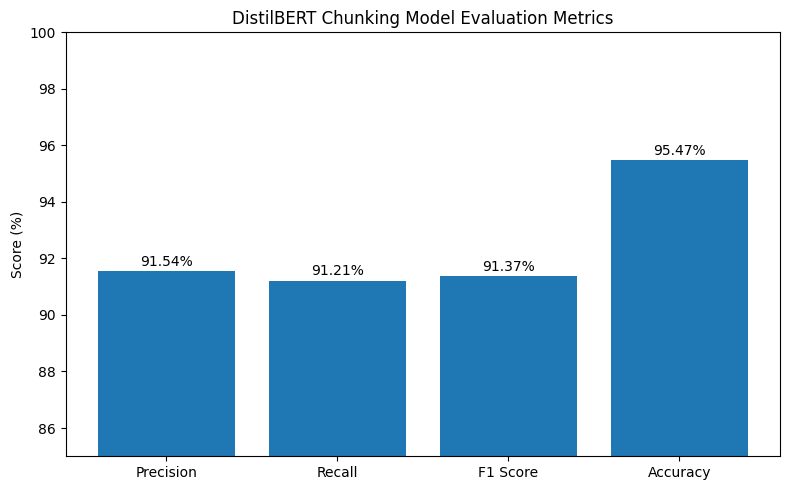

In [30]:
import matplotlib.pyplot as plt

# Evaluation metrics from your model
metrics = ["Precision", "Recall", "F1 Score", "Accuracy"]
values = [91.54, 91.21, 91.37, 95.47]

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, values)

plt.ylim(85, 100)
plt.ylabel("Score (%)")
plt.title("DistilBERT Chunking Model Evaluation Metrics")

# Add values on top of bars
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.2,
        f"{value:.2f}%",
        ha='center'
    )

plt.tight_layout()
plt.show()

POS Tagging vs Chunking difficulty and scope

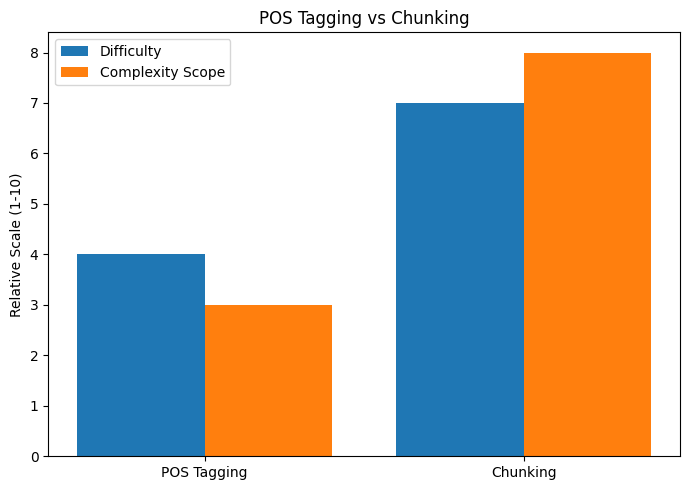

In [31]:
import matplotlib.pyplot as plt

tasks = ["POS Tagging", "Chunking"]
difficulty = [4, 7]      # relative difficulty out of 10
scope = [3, 8]           # word-level vs phrase-level complexity

x = range(len(tasks))

plt.figure(figsize=(7,5))
plt.bar(x, difficulty, width=0.4, label="Difficulty")
plt.bar([i + 0.4 for i in x], scope, width=0.4, label="Complexity Scope")

plt.xticks([i + 0.2 for i in x], tasks)
plt.ylabel("Relative Scale (1-10)")
plt.title("POS Tagging vs Chunking")
plt.legend()
plt.tight_layout()
plt.show()

# Compariosn

| Feature       | POS Tagging                            | Chunking                                   |
| ------------- | -------------------------------------- | ------------------------------------------ |
| Meaning       | Assigns a grammatical tag to each word | Groups words into meaningful phrases       |
| Example       | John → Noun, works → Verb              | John → Noun Phrase, works at → Verb Phrase |
| Level         | Word-level                             | Phrase-level                               |
| Difficulty    | Easier                                 | Slightly harder                            |
| Output Labels | NN, VB, JJ                             | B-NP, I-NP, B-VP                           |
| Use Cases     | Grammar checking, parsing              | Information extraction, NLP pipelines      |


# Final Report

“POS tagging and chunking are both token classification tasks performed using transformer models. POS tagging assigns a grammatical category to each word, while chunking groups multiple words into meaningful phrases such as noun phrases and verb phrases.

The main challenge in this assignment was aligning labels after tokenization. Since DistilBERT splits some words into subwords, we had to assign `-100` to ignored tokens and special tokens.

The model trained on CoNLL-2003 achieved strong results with approximately 91.5% precision, 91.2% recall, and 91.4% F1-score. Chunking was found to be more difficult than POS tagging because it requires identifying relationships between multiple words rather than only assigning labels to individual words.”
